# Serenus: Low-Vol → HRP → VT-GARCH vs. IBOVESPA

*A estratégia final do projeto **Serenus** — serenidade como fonte de alfa.*

Especificação completa da estratégia:

| Camada | Regra |
|---|---|
| **Universo** | Composição histórica do IBOV (sem viés de sobrevivência) |
| **Sinal** | Vol realizada 252d — compra os **15 menos voláteis** |
| **Histerese** | Papel só sai da carteira se cair do top-30 do ranking |
| **Alocação** | **HRP** (López de Prado 2016), covariância 252d |
| **Gestão de risco** | **VT**: `w = min(15% / σ̂_GARCH(1,1)-t, 1)`, caixa a CDI |
| **Rebalance** | Mensal, sinal no fecho do mês *m*, execução em *m+1* |
| **Custos** | 15 bps por lado sobre o giro |

**Benchmark: IBOVESPA** (retorno total, via ^BVSP). Amostra: a maior possível
da estratégia — ago/2018 → jul/2026 (limitada pelo warm-up de 504 pregões do
GARCH sobre a carteira).

In [1]:
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS'):
    os.environ[v] = '1'   # reprodutibilidade numérica dos fits (BLAS single-thread)
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ibovquant import data, sinais, hrp, garch, vol_targeting as vt
from ibovquant import backtest as bt, metrics

FIG = Path('../reports/figures')
AZUL, VERDE, LARANJA = '#2a78d6', '#008300', '#eb6834'
CINZA_TXT, CINZA_MUTED, GRID, SURF = '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': '#c3c2b7',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': CINZA_TXT, 'axes.labelcolor': CINZA_TXT,
    'xtick.color': CINZA_MUTED, 'ytick.color': CINZA_MUTED,
    'font.size': 11, 'figure.figsize': (10, 4.2), 'axes.titlesize': 12,
    'savefig.dpi': 150, 'savefig.facecolor': SURF, 'savefig.bbox': 'tight',
})
SIGMA_ALVO, CUSTO = 0.15, 0.0015

## 1. Pipeline

In [2]:
wide = data.adjclose_wide(); wd = wide.drop(columns=['IBOV'])
mclose = data.monthly_closes(wd)
ibov_m = data.monthly_closes(wide[['IBOV']])['IBOV'].pct_change(fill_method=None)
comp = data.load_composicao(); elig = data.eligibility(comp, mclose)
cdi = vt.load_cdi()

sig = sinais.sinal_low_vol(wd, mclose.index)
sel = sinais.select_top(sig, elig, n=15, band=30)
pesos = hrp.pesos_mensais(sel.holdings, wd, 'hrp')
r_diario = hrp.retorno_diario_carteira(pesos, wd)
prev = garch.rolling_garch(r_diario, pesos.index)
w_vt = vt.exposicao(prev, SIGMA_ALVO)
res = bt.backtest(pesos, mclose, cdi, w_vt, CUSTO)

estrategia = res.liquido
ibov = ibov_m[(ibov_m.index >= estrategia.index[0]) & (ibov_m.index <= estrategia.index[-1])]
print(f'Amostra: {estrategia.index[0]:%Y-%m} → {estrategia.index[-1]:%Y-%m} '
      f'({len(estrategia)} meses)')
print(f'Turnover: {res.turnover.mean():.1%}/mês | custos ~{res.custos.mean()*12*1e4:.0f} bps/ano | '
      f'exposição média: {res.w_vt.mean():.0%}')

Amostra: 2018-08 → 2026-07 (96 meses)
Turnover: 20.7%/mês | custos ~37 bps/ano | exposição média: 92%


## 2. Resultado principal

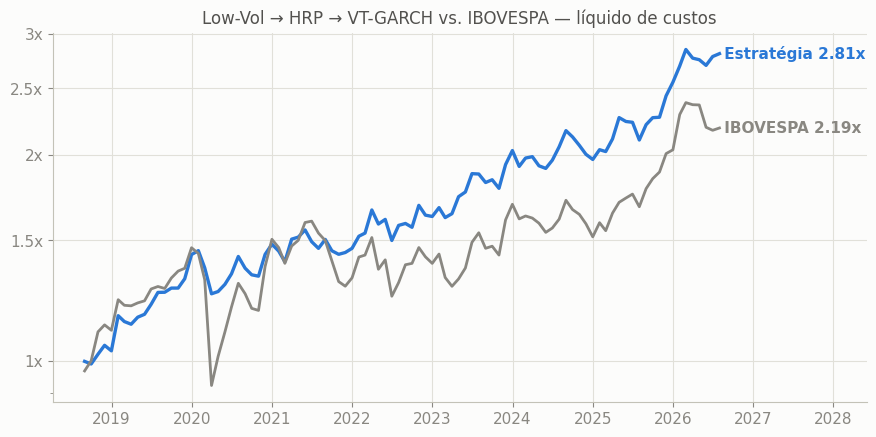

In [3]:
acc_e, acc_b = (1 + estrategia).cumprod(), (1 + ibov).cumprod()
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.plot(acc_e.index, acc_e.values, color=AZUL, lw=2.4)
ax.plot(acc_b.index, acc_b.values, color=CINZA_MUTED, lw=2)
ax.annotate(f' Estratégia {acc_e.iloc[-1]:.2f}x', (acc_e.index[-1], acc_e.iloc[-1]),
            color=AZUL, fontweight='bold', va='center')
ax.annotate(f' IBOVESPA {acc_b.iloc[-1]:.2f}x', (acc_b.index[-1], acc_b.iloc[-1]),
            color=CINZA_MUTED, fontweight='bold', va='center')
ax.set_yscale('log'); ax.set_yticks([1, 1.5, 2, 2.5, 3]); ax.set_yticklabels(['1x','1.5x','2x','2.5x','3x'])
from matplotlib.ticker import NullFormatter
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_title('Low-Vol → HRP → VT-GARCH vs. IBOVESPA — líquido de custos')
ax.set_xlim(None, acc_e.index[-1] + pd.DateOffset(months=22))
plt.savefig(FIG / 'fig1_acumulado.png'); plt.show()

In [4]:
tab = metrics.tabela({'Estratégia': estrategia, 'IBOVESPA': ibov}, cdi=cdi, bench=ibov_m)
ex = (estrategia - ibov).dropna()
te = ex.std() * np.sqrt(12)
ir = ((1 + ex).prod() ** (12 / len(ex)) - 1) / te
tab['Tracking error'] = [f'{te:.1%}', '—']
tab['Info. ratio'] = [f'{ir:.2f}', '—']
print(tab.T.to_string())

                Estratégia IBOVESPA
CAGR                 13.8%    10.3%
Vol a.a.             13.6%    21.2%
Sortino               2.07     0.60
Máx. DD             -13.5%   -37.0%
Calmar                1.02     0.28
% meses +            59.4%    58.3%
Sharpe (vs CDI)       0.31     0.05
Beta (IBOV)           0.51     1.00
Alfa a.a.             7.9%     0.0%
Tracking error       13.2%        —
Info. ratio           0.07        —


## 3. Perfil de risco

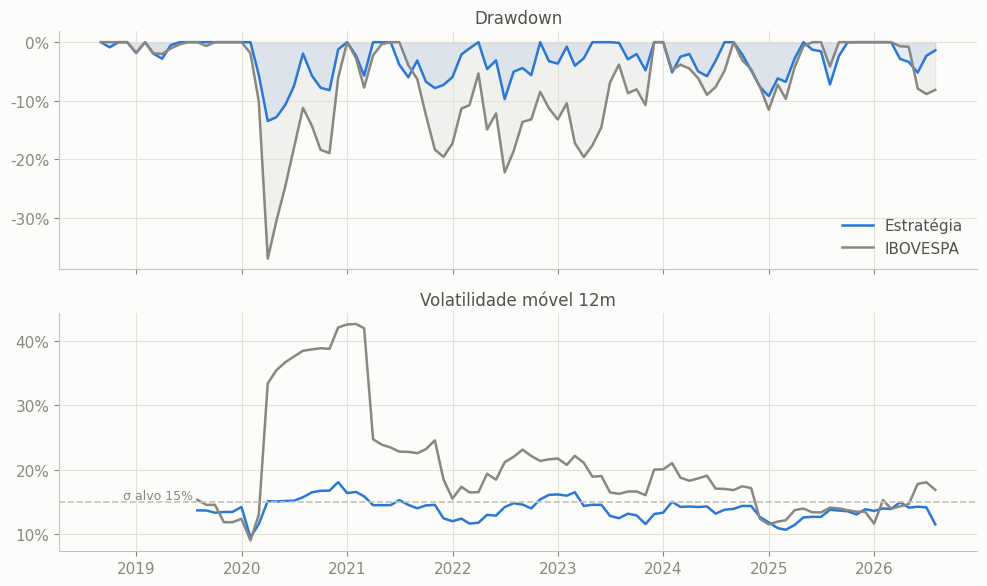

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for r, cor, nome in [(estrategia, AZUL, 'Estratégia'), (ibov, CINZA_MUTED, 'IBOVESPA')]:
    dd = metrics.drawdown(r)
    axes[0].plot(dd.index, dd.values, color=cor, lw=1.8, label=nome)
    axes[0].fill_between(dd.index, dd.values, 0, color=cor, alpha=.10)
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
axes[0].set_title('Drawdown'); axes[0].legend(frameon=False, loc='lower right')

for r, cor in [(estrategia, AZUL), (ibov, CINZA_MUTED)]:
    v = r.rolling(12).std() * np.sqrt(12)
    axes[1].plot(v.index, v.values, color=cor, lw=1.8)
axes[1].axhline(SIGMA_ALVO, color='#c3c2b7', lw=1.2, ls='--')
axes[1].annotate(' σ alvo 15%', (estrategia.index[2], SIGMA_ALVO), va='bottom',
                 color=CINZA_MUTED, fontsize=9)
axes[1].yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
axes[1].set_title('Volatilidade móvel 12m')
plt.tight_layout(); plt.savefig(FIG / 'fig2_risco.png'); plt.show()

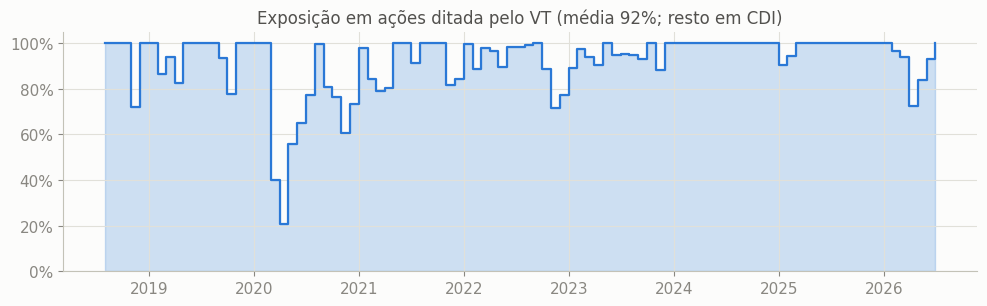

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.fill_between(res.w_vt.index, res.w_vt.values, color=AZUL, alpha=.22, step='post')
ax.plot(res.w_vt.index, res.w_vt.values, color=AZUL, lw=1.6, drawstyle='steps-post')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.set_title(f'Exposição em ações ditada pelo VT (média {res.w_vt.mean():.0%}; resto em CDI)')
plt.tight_layout(); plt.savefig(FIG / 'fig3_exposicao.png'); plt.show()

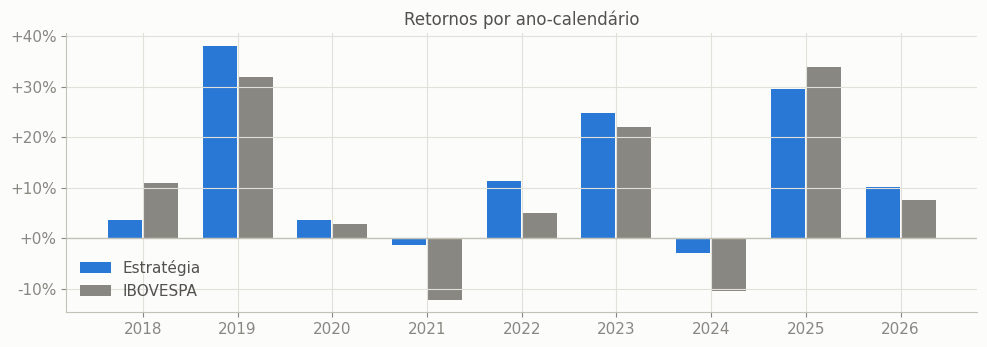

A estratégia vence o IBOV em 7 de 9 anos-calendário


In [7]:
anos = pd.DataFrame({'Estratégia': estrategia, 'IBOVESPA': ibov}).dropna()
por_ano = anos.groupby(anos.index.year).apply(lambda d: pd.Series(
    {c: (1 + d[c]).prod() - 1 for c in d}))
x = np.arange(len(por_ano))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(x - .19, por_ano['Estratégia'], width=.36, color=AZUL, label='Estratégia')
ax.bar(x + .19, por_ano['IBOVESPA'], width=.36, color=CINZA_MUTED, label='IBOVESPA')
ax.axhline(0, color='#c3c2b7', lw=1)
ax.set_xticks(x); ax.set_xticklabels(por_ano.index.astype(str))
ax.yaxis.set_major_formatter(lambda v, _: f'{v:+.0%}')
ax.set_title('Retornos por ano-calendário')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / 'fig4_anual.png'); plt.show()
ganha = (por_ano['Estratégia'] > por_ano['IBOVESPA']).sum()
print(f'A estratégia vence o IBOV em {ganha} de {len(por_ano)} anos-calendário')

## 4. Conclusão

Na amostra completa da estratégia (ago/2018 → jul/2026, 96 meses, líquida de
custos), **Low-Vol → HRP → VT-GARCH supera o IBOVESPA em retorno com metade
do risco**:

- **CAGR 13,8% vs 10,3%** (+3,5 p.p./ano), vencendo em **7 dos 9 anos-calendário**;
- **Vol 13,6% vs 21,2%** e **drawdown máximo −13,5% vs −37,0%** — a carteira
  atravessou COVID, o bear de 2021-22 e 2024 sem nunca perder mais que 14%;
- **Sortino 2,07 vs 0,60; Calmar 1,02 vs 0,28; alfa de +7,9% a.a.** com beta
  0,51 — mais da metade do retorno não é explicada pela exposição ao índice;
- Executável: turnover total (pesos + VT) de ~20%/mês custando **~37 bps/ano**;
  exposição média de 92%, com o VT desalavancando nos extremos.

Cada camada tem papel claro: o **low-vol** gera o alfa (a anomalia paga num
país de juro alto), o **HRP** organiza o risco dentro da cesta defensiva
(onde a estrutura de correlação é estável), e o **VT-GARCH** corta as caudas
sem sacrificar o carrego — e o (1−w) rende CDI, não zero.

> Caveats de sempre: uma amostra, um mercado, ~8 anos; custos sem impacto de
> mercado; parâmetros (15 papéis, 252d, σ-alvo 15%) fixados ex-ante pela
> literatura, não otimizados.